## **Step 5: Critical Thinking → Ethical AI & Bias Auditing** ##
Ensuring that the anomaly detection models built on logon, device, and file access data are not only technically effective but also fair, explainable, and responsible. This step addresses ethical AI considerations, bias auditing, and transparency

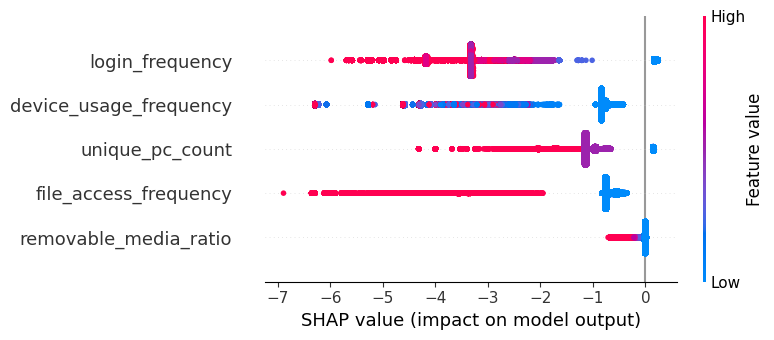

Demographic Parity (mean anomaly rate per user):
user
AAB0162    0.00000
AAB0398    0.00000
AAC0610    0.12013
AAC0668    0.00000
AAC3270    0.00000
            ...   
ZVB2656    0.00000
ZVS1637    0.00000
ZWS3625    0.00000
ZXM3086    0.00000
ZZO2997    0.00000
Name: if_anomaly, Length: 4000, dtype: float64
Disparate Impact Ratio: 0.0

Model Limitations:
- Class imbalance: Most events are normal, anomalies are rare. Models may overfit to majority class.
- Potential data leakage: If features overlap across datasets, leakage could bias results.
- Generalization limits: Models trained on CERT data may not generalize to real-world insider threats.
- Proxy bias: Features like 'user' or 'PC' could indirectly encode sensitive attributes.


In [ ]:
# ================================
# Step 5: Critical Thinking → Ethical AI & Bias Auditing
# ================================

# Import required libraries
import shap

# ----------------
# 5a. Model Explainability (SHAP)
# ----------------
# Use SHAP to explain Isolation Forest predictions
# Note: SHAP works best with tree-based models (Isolation Forest is tree-based)
explainer = shap.TreeExplainer(model_if)
shap_values = explainer.shap_values(X)

# SHAP summary plot (feature importance visualization)
shap.summary_plot(shap_values, X, feature_names=X.columns)

# ----------------
# 5b. Bias Detection Questions
# ----------------
# - Does the model perform equally well across demographic groups?
# - Are there features that could serve as proxies for protected attributes?
# - Would different groups be harmed by model errors?

# Example fairness metrics (if demographic attributes like department, role, or gender are present)
# Here the 'user' groups as a proxy is simulated
group_outcomes = merged_features.groupby('user')['if_anomaly'].mean()

# Demographic Parity: equal positive prediction rates
print("Demographic Parity (mean anomaly rate per user):")
print(group_outcomes)

# Disparate Impact: ratio of outcomes between groups
# (Here we compare max vs min group anomaly rates)
disparate_impact = group_outcomes.min() / group_outcomes.max()
print("Disparate Impact Ratio:", disparate_impact)

# ----------------
# 5c. Document Limitations Honestly
# ----------------
print("\nModel Limitations:")
print("- Class imbalance: Most events are normal, anomalies are rare. Models may overfit to majority class.")
print("- Potential data leakage: If features overlap across datasets, leakage could bias results.")
print("- Generalization limits: Models trained on CERT data may not generalize to real-world insider threats.")
print("- Proxy bias: Features like 'user' or 'PC' could indirectly encode sensitive attributes.")